# Deep Learning Part2 vs Foundation Models Benchmark


#Section 1. Data Set & Problem Definition

_This project main aim is on a multi-class image classification task that uses the CIFAR-10 dataset. The goal is to classify each image into one of 10 categories. The main goal is to compare traditional deep learning models with pretrained models and to evaluate performances. This problem is interesting because CIFAR-10 is a standard computer vision benchmark that allows us to study how pretrained models can improve classification problems._

*This project continues from a previous deep learning study on CIFAR-10, where a CNN built from scratch achieved ~84% accuracy.
It extends the work by applying foundation models: CLIP embeddings with an MLP and zero-shot CLIP classification.
The results show strong improvement, with ~97% accuracy for the pretrained model and ~90% for zero-shot LLM-based classification.

In [ ]:
#library
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from torch.utils.data import DataLoader, Subset, TensorDataset
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms

from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.linear_model import LogisticRegression

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device) # I'm using T4 gpu for speed.

Device: cuda


In [ ]:
# Dataset
torchvision.datasets.CIFAR10.url = "https://data.brainchip.com/dataset-mirror/cifar10/cifar-10-python.tar.gz"


transform = transforms.ToTensor()

train_dataset = torchvision.datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = torchvision.datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

classes = train_dataset.classes

print("Classes:", classes)
print("Train size:", len(train_dataset))
print("Test size:", len(test_dataset))


100%|██████████| 170M/170M [00:30<00:00, 5.59MB/s]


Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
Train size: 50000
Test size: 10000


#Section 2. Embedding Model + Transfer Learning

In [ ]:
# Pretrained model
!pip install open_clip_torch # run this if gives error!
import open_clip

#load
clip_model, _, preprocess = open_clip.create_model_and_transforms(
    'ViT-B-32',
    pretrained='laion2b_s34b_b79k'
)

clip_model = clip_model.to(device)
clip_model.eval() # freeze backbone

In [ ]:
# # subset to speed up runtime.
# train_dataset = Subset(train_dataset, range(10000))
# test_dataset = Subset(test_dataset, range(2000))

#converting image to numerical vector embedding
class CIFAR_CLIP(torch.utils.data.Dataset):
    def __init__(self, dataset, preprocess):
        self.dataset = dataset
        self.preprocess = preprocess

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        img, label = self.dataset[idx]
        img = self.preprocess(img)
        return img, label

# Wrap dataset
train_clip = CIFAR_CLIP(train_dataset, preprocess)
test_clip = CIFAR_CLIP(test_dataset, preprocess)

train_loader = DataLoader(train_clip, batch_size=256, shuffle=True)
test_loader = DataLoader(test_clip, batch_size=256, shuffle=False)



In [ ]:
# Extract embeddings
def get_embeddings(loader):
    features, labels = [], []

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)

            emb = clip_model.encode_image(x)
            emb = emb / emb.norm(dim=-1, keepdim=True)

            features.append(emb.cpu())
            labels.append(y)

    return torch.cat(features), torch.cat(labels)

X_train, y_train = get_embeddings(train_loader)
X_test, y_test = get_embeddings(test_loader)

print("Train embeddings:", X_train.shape)
print("Test embeddings:", X_test.shape)

# Convert to PyTorch dataset
train_ds = TensorDataset(X_train.float(), y_train.long())
test_ds = TensorDataset(X_test.float(), y_test.long())

train_loader = DataLoader(train_ds, batch_size=128, shuffle=True)
val_loader = DataLoader(test_ds, batch_size=128, shuffle=False)


Train embeddings: torch.Size([50000, 512])
Test embeddings: torch.Size([10000, 512])


In [ ]:
# Multi layer MLP
model = nn.Sequential(
    # Layer 1
    nn.Linear(512, 256),
    nn.ReLU(),
    nn.Dropout(0.2),

    # Layer 2
    nn.Linear(256, 128),
    nn.ReLU(),
    nn.Dropout(0.2),

    #output
    nn.Linear(128, 10)
).to(device)

# ======================================
# Loss + Optimizer

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3,weight_decay=1e-4)
criterion = nn.CrossEntropyLoss()

Epoch 1/10 | Train Loss: 0.3951 | Val Loss: 0.1190
Epoch 2/10 | Train Loss: 0.1152 | Val Loss: 0.1103
Epoch 3/10 | Train Loss: 0.1055 | Val Loss: 0.1106
Epoch 4/10 | Train Loss: 0.0994 | Val Loss: 0.1017
Epoch 5/10 | Train Loss: 0.0952 | Val Loss: 0.1056
Epoch 6/10 | Train Loss: 0.0916 | Val Loss: 0.1016
Epoch 7/10 | Train Loss: 0.0873 | Val Loss: 0.1036
Epoch 8/10 | Train Loss: 0.0862 | Val Loss: 0.1012
Epoch 9/10 | Train Loss: 0.0835 | Val Loss: 0.0993
Epoch 10/10 | Train Loss: 0.0818 | Val Loss: 0.0998


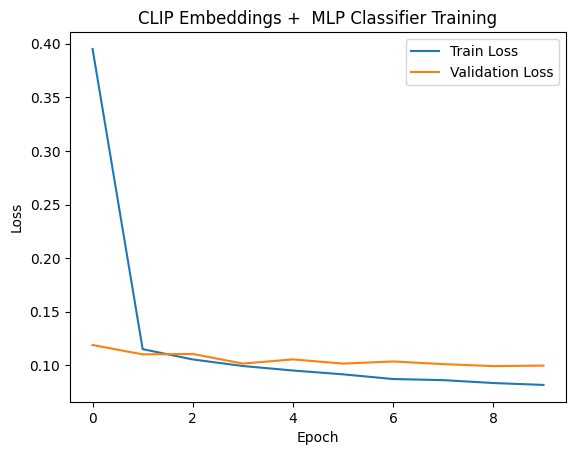

In [ ]:
# =========================================
# Training Loop (with loss tracking)
# =========================================
epochs = 10

train_losses = []
val_losses = []

for epoch in range(epochs):
    model.train()
    total_train_loss = 0

    for x, y in train_loader:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()

        total_train_loss += loss.item()

    train_losses.append(total_train_loss / len(train_loader))

    # Validation
    model.eval()
    total_val_loss = 0

    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device), y.to(device)
            out = model(x)
            loss = criterion(out, y)
            total_val_loss += loss.item()

    val_losses.append(total_val_loss / len(val_loader))

    print(f"Epoch {epoch+1}/{epochs} | Train Loss: {train_losses[-1]:.4f} | Val Loss: {val_losses[-1]:.4f}")

plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CLIP Embeddings +  MLP Classifier Training")
plt.legend()
plt.show()

#Section 3. Large-Language Model

In [ ]:
!pip install transformers accelerate

In [ ]:
import random
from transformers import pipeline
from torchvision.transforms.functional import to_pil_image
from sklearn.metrics import accuracy_score

In [ ]:
#llm
device_id = 0 if torch.cuda.is_available() else -1

clf = pipeline(
    "zero-shot-image-classification",
    model="openai/clip-vit-base-patch32",
    device=device_id
)

In [ ]:

# This is the prompt: the list of class names we give the model.
candidate_labels = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]


In [ ]:
# Evaluate on 200 samples
sample_size = 200
subset_indices = random.sample(range(len(test_dataset)), sample_size)

y_true = []
y_pred = []

print(f"<<<<<< Running LLM inference on {sample_size} samples >>>>>>\n")

for idx in subset_indices:
    img, label = test_dataset[idx]

    # Convert tensor to PIL image and resize
    img_pil = to_pil_image(img).resize((224, 224))

    result = clf(img_pil, candidate_labels=candidate_labels)
    pred = result[0]["label"]

    y_true.append(candidate_labels[label])
    y_pred.append(pred)

    print(f"True: {candidate_labels[label]:<12} || Pred: {pred:<12}")

print("<","=" * 40, ">")

<<<<<< Running LLM inference on 200 samples >>>>>>

True: airplane     || Pred: airplane    
True: frog         || Pred: frog        
True: truck        || Pred: truck       
True: deer         || Pred: deer        
True: dog          || Pred: dog         
True: deer         || Pred: deer        
True: dog          || Pred: dog         
True: frog         || Pred: dog         


You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


True: ship         || Pred: ship        
True: airplane     || Pred: airplane    
True: cat          || Pred: cat         
True: truck        || Pred: truck       
True: dog          || Pred: dog         
True: deer         || Pred: deer        
True: bird         || Pred: bird        
True: automobile   || Pred: automobile  
True: airplane     || Pred: airplane    
True: truck        || Pred: truck       
True: ship         || Pred: ship        
True: frog         || Pred: airplane    
True: cat          || Pred: deer        
True: deer         || Pred: deer        
True: cat          || Pred: cat         
True: ship         || Pred: ship        
True: airplane     || Pred: airplane    
True: frog         || Pred: bird        
True: truck        || Pred: truck       
True: airplane     || Pred: airplane    
True: automobile   || Pred: automobile  
True: dog          || Pred: dog         
True: automobile   || Pred: automobile  
True: dog          || Pred: dog         
True: horse     

In [ ]:
# accuracy
acc = accuracy_score(y_true, y_pred)
print(f"\nFinal LLM Accuracy: {acc * 100:.2f}%")


Final LLM Accuracy: 89.00%


#Section 4. Evaluation


In [ ]:
# Evaluation
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score, confusion_matrix)

classes = ["airplane", "automobile", "bird", "cat", "deer",
           "dog", "frog", "horse", "ship", "truck"]


In [ ]:
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for x, y in val_loader:
        out = model(x.to(device))
        all_preds.extend(out.argmax(dim=1).cpu().numpy())
        all_labels.extend(y.numpy())

#Convert LLM string to integers
label2idx = {c: i for i, c in enumerate(classes)}
y_true_llm = [label2idx[l] for l in y_true]
y_pred_llm = [label2idx[l] for l in y_pred]

In [ ]:
# Metrics
print("<<<<< Metrics acc, prec, recall and F1 scores >>>>>>\n")

for name, yt, yp in [("CLIP Embeddings + MLP", all_labels, all_preds),
                      ("CLIP Zero-Shot LLM",    y_true_llm, y_pred_llm)]:
    print("="*25)
    print(f"{name}")
    print(f"  Accuracy : {accuracy_score(yt, yp)*100:.2f}%")
    print(f"  Precision: {precision_score(yt, yp, average='macro', zero_division=0)*100:.2f}%")
    print(f"  Recall   : {recall_score(yt, yp, average='macro', zero_division=0)*100:.2f}%")
    print(f"  F1-Score : {f1_score(yt, yp, average='macro', zero_division=0)*100:.2f}%")

    print("="*25)


<<<<< Metrics acc, prec, recall and F1 scores >>>>>>

CLIP Embeddings + MLP
  Accuracy : 96.68%
  Precision: 96.68%
  Recall   : 96.68%
  F1-Score : 96.67%
CLIP Zero-Shot LLM
  Accuracy : 89.00%
  Precision: 88.86%
  Recall   : 89.74%
  F1-Score : 88.77%


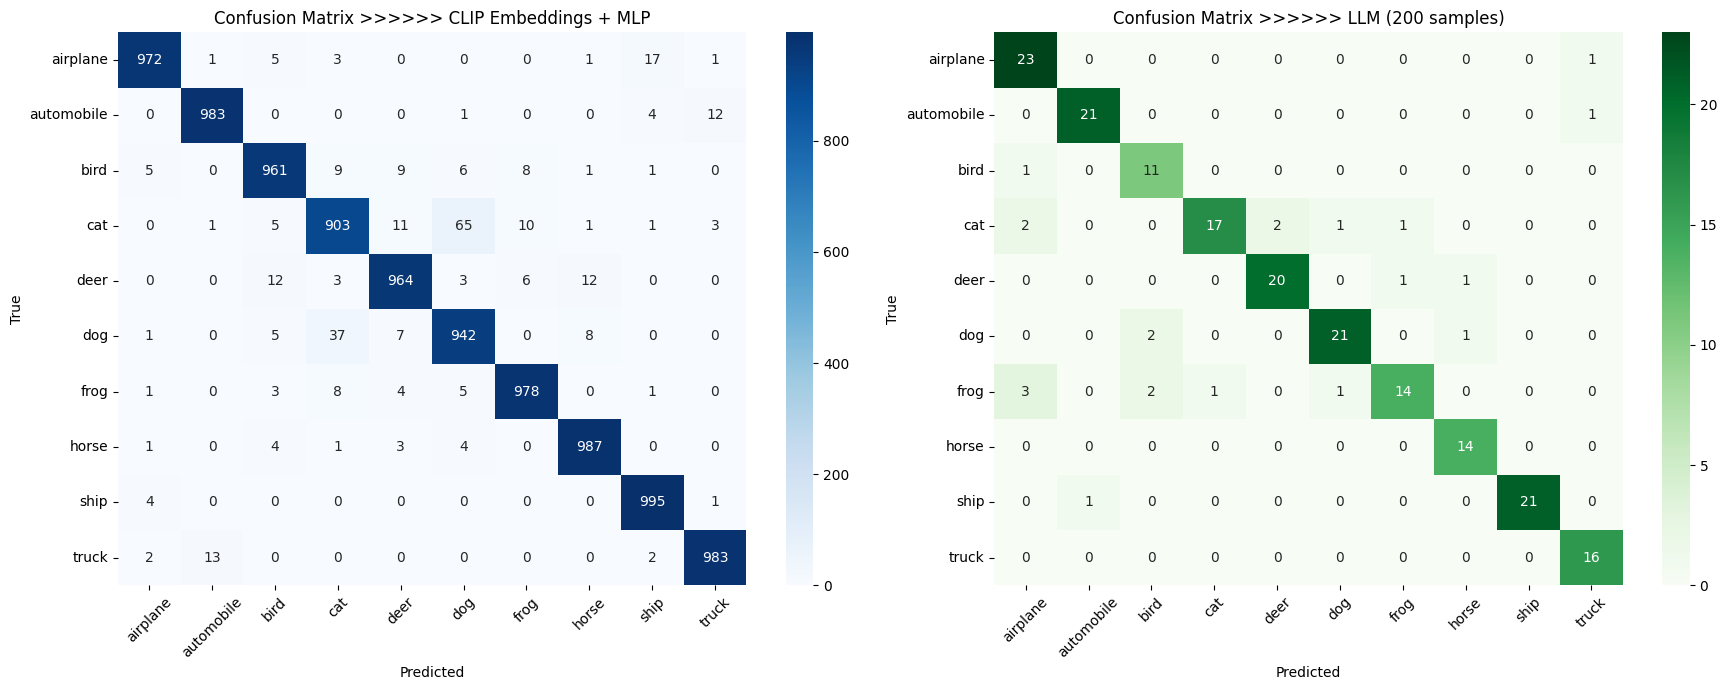

In [ ]:
# Two Confusion Matrices
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.heatmap(confusion_matrix(all_labels, all_preds), annot=True, fmt='d',
            cmap='Blues', xticklabels=classes, yticklabels=classes, ax=axes[0])
axes[0].set_title("Confusion Matrix >>>>>> CLIP Embeddings + MLP")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("True")
axes[0].tick_params(axis='x', rotation=45)

# ========================================================================

sns.heatmap(confusion_matrix(y_true_llm, y_pred_llm), annot=True, fmt='d',
            cmap='Greens', xticklabels=classes, yticklabels=classes, ax=axes[1])
axes[1].set_title("Confusion Matrix >>>>>> LLM (200 samples)")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("True")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig("confusion_matrices.png", dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Failure Cases
print("\n <<< Failure Cases <—> CLIP Embeddings + MLP >>> \n")
count = 0
for i, (t, p) in enumerate(zip(all_labels, all_preds)):
    if t != p and count < 5: # top 10 examples
        print(f"  Sample {i:<3} | True: {classes[t]:<10} -> Predicted: {classes[p]}")
        count += 1
print("\n","="*55)

print("\n <<< Failure Cases <—> Zero-Shot LLM >>> \n")
count = 0
for i, (t, p) in enumerate(zip(y_true, y_pred)):
    if t != p and count < 5:
        print(f"  Sample {i:<3} | True: {t:<11} -> Predicted: {p}")
        count += 1


 <<< Failure Cases <—> CLIP Embeddings + MLP >>> 

  Sample 58  | True: deer       -> Predicted: bird
  Sample 59  | True: frog       -> Predicted: dog
  Sample 61  | True: cat        -> Predicted: dog
  Sample 68  | True: cat        -> Predicted: dog
  Sample 74  | True: airplane   -> Predicted: truck


 <<< Failure Cases <—> Zero-Shot LLM >>> 

  Sample 7   | True: frog        -> Predicted: dog
  Sample 19  | True: frog        -> Predicted: airplane
  Sample 20  | True: cat         -> Predicted: deer
  Sample 25  | True: frog        -> Predicted: bird
  Sample 40  | True: frog        -> Predicted: cat
